# Client Order Flow — Poisson Arrival Model

Demonstrates the `client_flow` module: Poisson arrival rates, power-law order sizes,
and integration with Exchange A's order book.

**Theory:** Avellaneda & Stoikov (2006), Sections 2.4–2.5
- Arrival intensity: $\lambda(\delta) = A \cdot e^{-k \delta}$
- Order size distribution: $f^Q(x) \propto x^{-1-\alpha}$, $\alpha \approx 1.5$

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.client_flow.flow_generator import ClientFlowGenerator, ClientFlowConfig
from utils.client_flow.arrival import intensity
from utils.client_flow.size_model import sample_size

## 1. Intensity function $\lambda(\delta) = A \cdot e^{-k\delta}$

The further our quote is from mid, the fewer client orders hit it.

$\delta$ is expressed in **basis points** (1 bp = 0.0001 for EUR/USD). With $k = 1.5$, the intensity halves every $\ln(2)/k \approx 0.46$ bps — a quote 5 bps away from mid sees almost no flow.

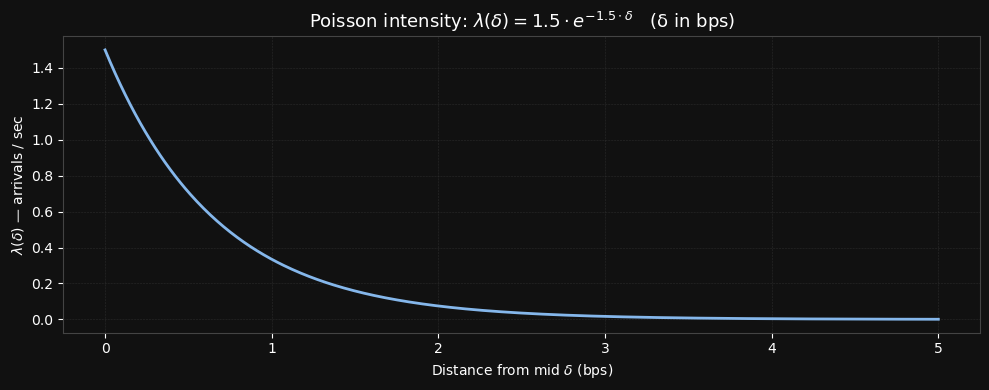

At δ = 0 bps:  λ = 1.5000 / sec
At δ = 1 bp:   λ = 0.3347 / sec
At δ = 2 bps:  λ = 0.0747 / sec
At δ = 5 bps:  λ = 0.0008 / sec

Half-life: λ drops to 50% at δ = 0.46 bps


In [2]:
A, k = 1.5, 1.5
deltas_bps = np.linspace(0, 5, 500)  # 0 to 5 bps
lambdas = [intensity(d, A, k) for d in deltas_bps]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')
ax.plot(deltas_bps, lambdas, color='#85b7eb', linewidth=2)
ax.set_xlabel('Distance from mid $\\delta$ (bps)', color='white')
ax.set_ylabel('$\\lambda(\\delta)$ — arrivals / sec', color='white')
ax.set_title(f'Poisson intensity: $\\lambda(\\delta) = {A} \\cdot e^{{-{k} \\cdot \\delta}}$   (δ in bps)', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
for spine in ax.spines.values(): spine.set_color('#444444')
plt.tight_layout()
plt.show()

print(f'At δ = 0 bps:  λ = {intensity(0, A, k):.4f} / sec')
print(f'At δ = 1 bp:   λ = {intensity(1, A, k):.4f} / sec')
print(f'At δ = 2 bps:  λ = {intensity(2, A, k):.4f} / sec')
print(f'At δ = 5 bps:  λ = {intensity(5, A, k):.4f} / sec')
print(f'\nHalf-life: λ drops to 50% at δ = {np.log(2)/k:.2f} bps')

## 2. Power-law size distribution

Order sizes follow a truncated Pareto: $f^Q(x) \propto x^{-1-\alpha}$ with $\alpha = 1.5$.
Most orders are small, but rare large orders occur — heavy tail.

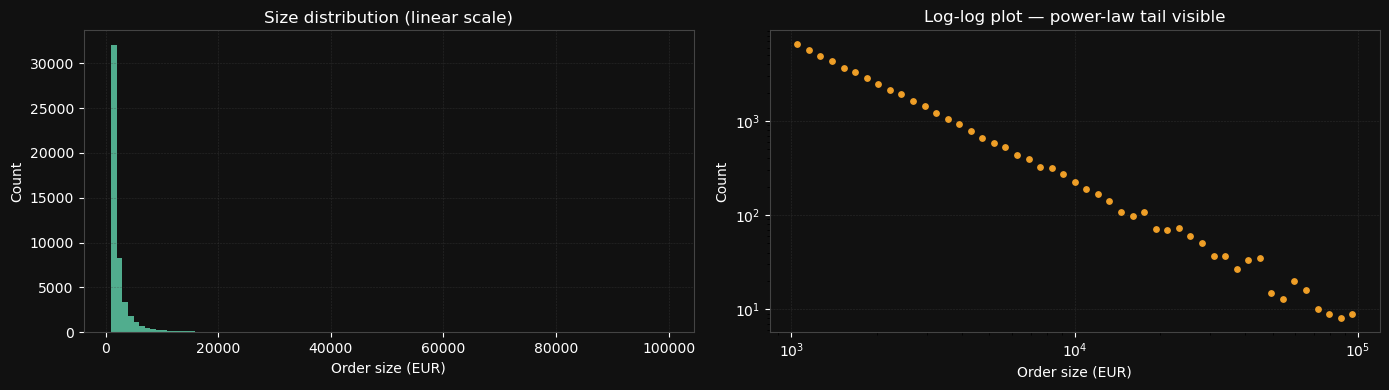

Samples: 50,000
Mean: 2,711 EUR | Median: 1,593 EUR
Min: 1,000 | Max: 99,585
Pct > 10k: 3.0%
Pct > 50k: 0.2%


In [3]:
rng = np.random.default_rng(42)
sizes = [sample_size(alpha=1.5, x_min=1_000, x_max=100_000, rng=rng) for _ in range(50_000)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#111111')

for ax in (ax1, ax2):
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
    for spine in ax.spines.values(): spine.set_color('#444444')

# Linear histogram
ax1.hist(sizes, bins=100, color='#5dcaa5', alpha=0.85, edgecolor='none')
ax1.set_xlabel('Order size (EUR)', color='white')
ax1.set_ylabel('Count', color='white')
ax1.set_title('Size distribution (linear scale)', color='white', fontsize=12)

# Log-log histogram — should be approximately linear with slope -(1+α)
counts, bin_edges = np.histogram(sizes, bins=np.logspace(np.log10(1000), np.log10(100_000), 50))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mask = counts > 0
ax2.scatter(bin_centers[mask], counts[mask], color='#ef9f27', s=15, zorder=3)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Order size (EUR)', color='white')
ax2.set_ylabel('Count', color='white')
ax2.set_title('Log-log plot — power-law tail visible', color='white', fontsize=12)

plt.tight_layout()
plt.show()

print(f'Samples: {len(sizes):,}')
print(f'Mean: {np.mean(sizes):,.0f} EUR | Median: {np.median(sizes):,.0f} EUR')
print(f'Min: {np.min(sizes):,} | Max: {np.max(sizes):,}')
print(f'Pct > 10k: {100 * np.mean(np.array(sizes) > 10_000):.1f}%')
print(f'Pct > 50k: {100 * np.mean(np.array(sizes) > 50_000):.1f}%')

## 3. Generate a session of client orders

We simulate a synthetic mid/bid/ask over 5000 steps and generate the client order stream.

With $k=1.5$ the intensity drops fast: $\lambda(0.5 \text{ bp}) \approx 0.71$ /sec but $\lambda(5 \text{ bps}) \approx 0.001$ /sec. We use a tight 0.5bp half-spread to see meaningful flow.

In [4]:
# Synthetic price path: random walk around 1.10
np.random.seed(123)
n_steps = 5_000
dt = 0.1  # 100ms steps

mid = 1.10 + np.cumsum(np.random.normal(0, 0.00001, n_steps + 1))
half_spread = 0.00005  # 0.5 bps — tight spread → decent arrival rate
bid = mid - half_spread
ask = mid + half_spread

# With δ ≈ 0.45 bps: λ ≈ 1.5·exp(-1.5·0.45) ≈ 0.76/sec per side
cfg = ClientFlowConfig(A_buy=1.5, A_sell=1.5, k_buy=1.5, k_sell=1.5)
gen = ClientFlowGenerator(config=cfg, seed=42)

session = gen.generate_session(mid, bid, ask, dt=dt)

print(f'Session: {n_steps} steps x {dt}s = {n_steps * dt:.0f}s ({n_steps * dt / 60:.1f} min)')
print(f'Half-spread: {half_spread*10_000:.1f} bps')
print(f'Total client orders: {len(session)}')

if len(session) > 0:
    n_buy  = sum(1 for _, o in session if o._direction == 'buy')
    n_sell = sum(1 for _, o in session if o._direction == 'sell')
    n_mo   = sum(1 for _, o in session if o._type == 'market_order')
    n_lo   = sum(1 for _, o in session if o._type == 'limit_order')
    print(f'Buy: {n_buy} | Sell: {n_sell}')
    print(f'Market orders: {n_mo} ({100*n_mo/len(session):.0f}%) | Limit orders: {n_lo} ({100*n_lo/len(session):.0f}%)')
    print(f'Avg arrivals/step: {len(session)/n_steps:.3f}')
    print(f'Avg arrivals/sec:  {len(session)/(n_steps*dt):.3f}')
else:
    print('No arrivals — spread too wide for these parameters. Try increasing A or decreasing k.')

Session: 5000 steps x 0.1s = 500s (8.3 min)
Half-spread: 0.5 bps
Total client orders: 768
Buy: 393 | Sell: 375
Market orders: 388 (51%) | Limit orders: 380 (49%)
Avg arrivals/step: 0.154
Avg arrivals/sec:  1.536


## 4. Arrival timing analysis

Visualise when orders arrive during the session and check the inter-arrival distribution.

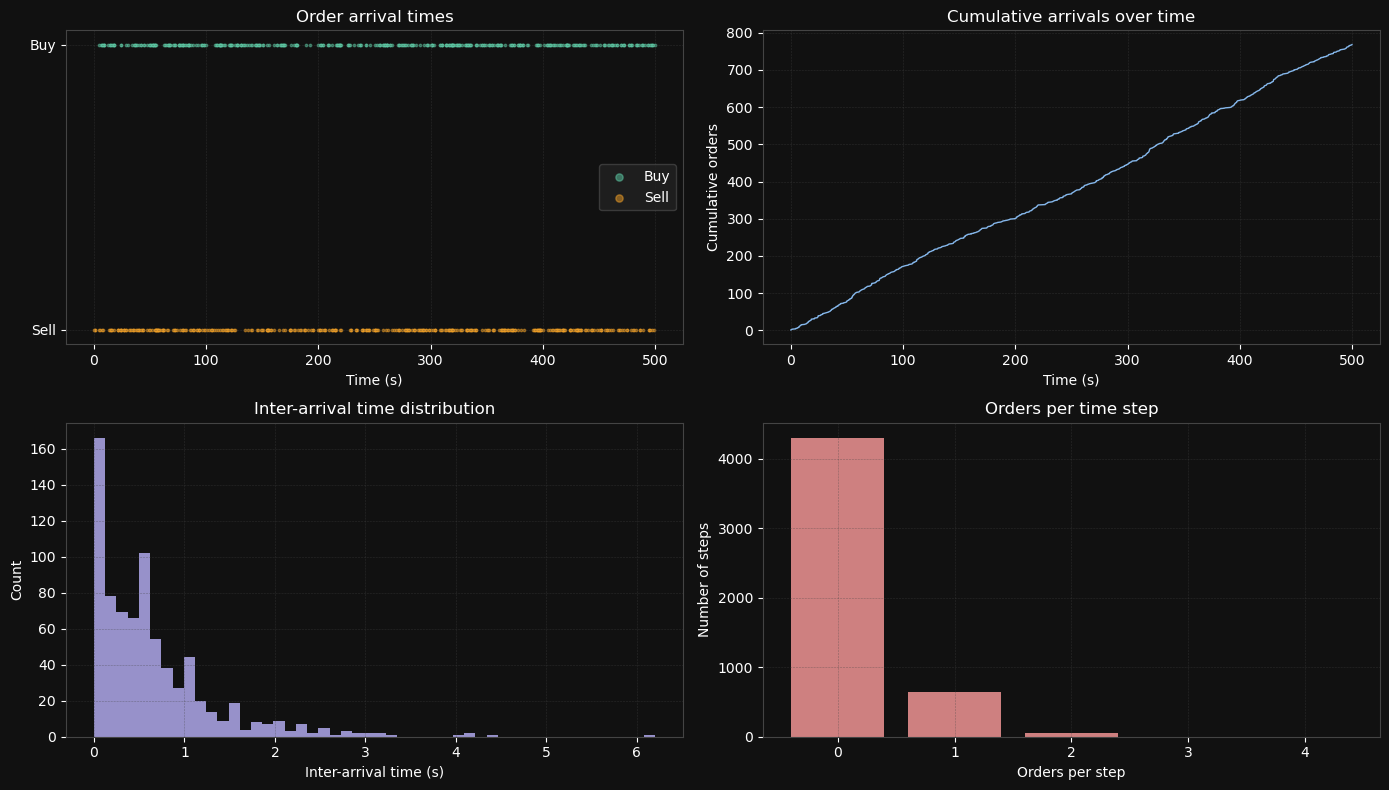

In [5]:
steps_buy  = [s for s, o in session if o._direction == 'buy']
steps_sell = [s for s, o in session if o._direction == 'sell']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#111111')

for ax in axes.flat:
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
    for spine in ax.spines.values(): spine.set_color('#444444')

# Top-left: arrival times scatter
ax = axes[0, 0]
ax.scatter([s * dt for s in steps_buy], [1] * len(steps_buy), color='#5dcaa5', s=3, alpha=0.5, label='Buy')
ax.scatter([s * dt for s in steps_sell], [0] * len(steps_sell), color='#ef9f27', s=3, alpha=0.5, label='Sell')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Sell', 'Buy'], color='white')
ax.set_xlabel('Time (s)', color='white')
ax.set_title('Order arrival times', color='white', fontsize=12)
ax.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white', markerscale=3)

# Top-right: cumulative arrivals
ax = axes[0, 1]
all_steps_sorted = sorted([s for s, _ in session])
ax.plot([s * dt for s in all_steps_sorted], range(1, len(all_steps_sorted) + 1), color='#85b7eb', linewidth=1)
ax.set_xlabel('Time (s)', color='white')
ax.set_ylabel('Cumulative orders', color='white')
ax.set_title('Cumulative arrivals over time', color='white', fontsize=12)

# Bottom-left: inter-arrival time histogram (in steps)
ax = axes[1, 0]
if len(all_steps_sorted) > 1:
    inter_arrivals = np.diff(all_steps_sorted) * dt
    ax.hist(inter_arrivals, bins=50, color='#afa9ec', alpha=0.85, edgecolor='none')
ax.set_xlabel('Inter-arrival time (s)', color='white')
ax.set_ylabel('Count', color='white')
ax.set_title('Inter-arrival time distribution', color='white', fontsize=12)

# Bottom-right: orders per step histogram
ax = axes[1, 1]
orders_per_step = np.zeros(n_steps + 1)
for s, _ in session:
    orders_per_step[s] += 1
counts = [int(np.sum(orders_per_step == i)) for i in range(5)]
ax.bar(range(len(counts)), counts, color='#f09595', alpha=0.85)
ax.set_xticks(range(len(counts)))
ax.set_xlabel('Orders per step', color='white')
ax.set_ylabel('Number of steps', color='white')
ax.set_title('Orders per time step', color='white', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Order types and sizes

Check the 50/50 market/limit split and the power-law size distribution of generated orders.

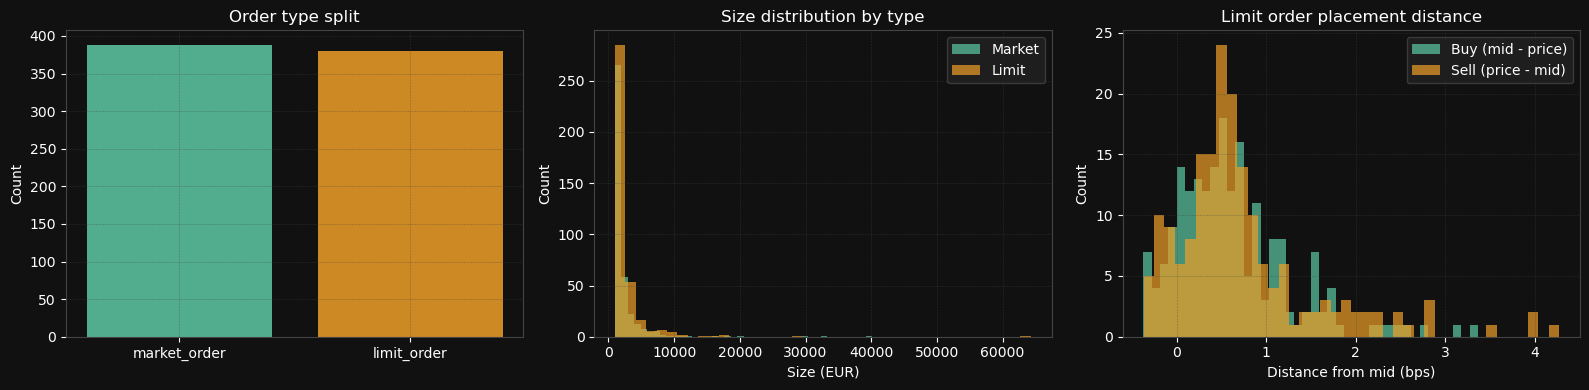

In [6]:
df_orders = pd.DataFrame([
    {'step': s, 'direction': o._direction, 'type': o._type,
     'price': o._price, 'size': o._size}
    for s, o in session
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#111111')

for ax in axes:
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
    for spine in ax.spines.values(): spine.set_color('#444444')

# Left: type breakdown
type_counts = df_orders['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['#5dcaa5', '#ef9f27'], alpha=0.85)
axes[0].set_title('Order type split', color='white', fontsize=12)
axes[0].set_ylabel('Count', color='white')

# Middle: size distribution by type
mo_sizes = df_orders[df_orders['type'] == 'market_order']['size']
lo_sizes = df_orders[df_orders['type'] == 'limit_order']['size']
axes[1].hist(mo_sizes, bins=40, color='#5dcaa5', alpha=0.7, label='Market', edgecolor='none')
axes[1].hist(lo_sizes, bins=40, color='#ef9f27', alpha=0.7, label='Limit', edgecolor='none')
axes[1].set_xlabel('Size (EUR)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_title('Size distribution by type', color='white', fontsize=12)
axes[1].legend(facecolor='#222222', edgecolor='#444444', labelcolor='white')

# Right: limit order price offsets from mid
lo_buy = df_orders[(df_orders['type'] == 'limit_order') & (df_orders['direction'] == 'buy')]
lo_sell = df_orders[(df_orders['type'] == 'limit_order') & (df_orders['direction'] == 'sell')]
if not lo_buy.empty:
    buy_offsets = [(mid[s] - p) * 10_000 for s, p in zip(lo_buy['step'], lo_buy['price'])]
    axes[2].hist(buy_offsets, bins=40, color='#5dcaa5', alpha=0.7, label='Buy (mid - price)', edgecolor='none')
if not lo_sell.empty:
    sell_offsets = [(p - mid[s]) * 10_000 for s, p in zip(lo_sell['step'], lo_sell['price'])]
    axes[2].hist(sell_offsets, bins=40, color='#ef9f27', alpha=0.7, label='Sell (price - mid)', edgecolor='none')
axes[2].set_xlabel('Distance from mid (bps)', color='white')
axes[2].set_ylabel('Count', color='white')
axes[2].set_title('Limit order placement distance', color='white', fontsize=12)
axes[2].legend(facecolor='#222222', edgecolor='#444444', labelcolor='white')

plt.tight_layout()
plt.show()

## 6. Integration with Exchange A's order book

Step-by-step workflow for a single simulation tick:
1. **Seed** the MM order book with random orders
2. **Generate** client orders from the current book state (one step)
3. **Inspect** the client orders
4. **Add** client orders to the book
5. **Clear** — match crossing orders

In [7]:
from utils.order_book.order_book_impl import Order_book

# ── 1. Seed the MM order book ──────────────────────────────────────────────
ob = Order_book()
ob._generate_n_random_order(40)

best_bid = ob._df_bid_book['Price'].max()
best_ask = ob._df_ask_book['Price'].min()
fair_mid = (best_bid + best_ask) / 2.0

print(f'MM book seeded: {len(ob._df_order_book)} orders')
print(f'Best bid: {best_bid:.4f} | Best ask: {best_ask:.4f} | Mid: {fair_mid:.4f}')
print(f'Spread: {(best_ask - best_bid) / fair_mid * 10_000:.2f} bps')

Generating order book: 100%|██████████| 40/40 [00:00<00:00, 278.60it/s]

MM book seeded: 41 orders
Best bid: 100.7885 | Best ask: 100.7886 | Mid: 100.7886
Spread: 0.01 bps


In [8]:
# ── 2. Generate client orders for one step ─────────────────────────────────
gen = ClientFlowGenerator(seed=42)          # uses default config (A=12, k=1.5)
dt = 0.5                                     # one step = 0.5 seconds

client_orders = gen.generate_step(
    mid_price=fair_mid,
    best_bid=best_bid,
    best_ask=best_ask,
    dt=dt,
)

# ── 3. Show client orders ─────────────────────────────────────────────────
n_buy  = sum(1 for o in client_orders if o._direction == 'buy')
n_sell = sum(1 for o in client_orders if o._direction == 'sell')
print(f'Client orders this step: {len(client_orders)}  ({n_buy} buys, {n_sell} sells)\n')

print(f'{"Dir":<6}{"Type":<16}{"Price":<12}{"Size":>10}')
print('-' * 45)
for o in client_orders:
    print(f'{o._direction:<6}{o._type:<16}{o._price:<12.4f}{o._size:>10,}')

Client orders this step: 15  (8 buys, 7 sells)

Dir   Type            Price             Size
---------------------------------------------
buy   market_order    100.7886         1,490
buy   limit_order     100.7860         5,665
buy   market_order    100.7886         1,477
buy   market_order    100.7886         1,713
buy   limit_order     100.7802         3,218
buy   limit_order     100.7803         1,338
buy   market_order    100.7886         2,724
buy   market_order    100.7886         1,520
sell  market_order    100.7885         1,097
sell  limit_order     100.7975         1,187
sell  limit_order     100.7890         3,282
sell  limit_order     100.7961         3,277
sell  limit_order     100.7897         1,254
sell  market_order    100.7885         1,160
sell  limit_order     100.8154         2,796


In [9]:
# ── 4. Add client orders to the book ───────────────────────────────────────
book_size_before = len(ob._df_order_book)
ob._add_orders_batch(client_orders)
print(f'Book size: {book_size_before} -> {len(ob._df_order_book)}  (+{len(client_orders)} client orders added)')
print(f'Matches before clearing: {len(ob._df_matches)}')

# ── 5. Clear — match crossing orders ──────────────────────────────────────
ob.try_clear()
print(f'Matches after clearing : {len(ob._df_matches)}')
print(f'Book size after clearing: {len(ob._df_order_book)}')
print()

if not ob._df_matches.empty:
    print('=== Matches ===')
    print(ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]].to_string(index=False))
    print(f'\nTotal matched volume: {ob._df_matches["MatchedSize"].sum():,.0f} EUR')
else:
    print('No matches — client orders did not cross MM quotes.')

Adding orders: 100%|██████████| 15/15 [00:00<00:00, 517.21it/s]

Book size: 41 -> 56  (+15 client orders added)
Matches before clearing: 0
Matches after clearing : 11
Book size after clearing: 45

=== Matches ===
Direction    Price  MatchedSize      ClientOrderId          MmOrderId
      buy 100.7886         1490 1776277817631_9172 1776277817524_0502
      buy 100.7886          505 1776277817631_4517 1776277817524_0502
      buy 100.7886          972 1776277817631_4517 1776277817531_5394
      buy 100.7886          920 1776277817631_5979 1776277817531_5394
      buy 100.7886          793 1776277817631_5979 1776277817555_2916
      buy 100.7886         1068 1776277817631_0966 1776277817555_2916
      buy 100.7886         1656 1776277817631_0966 1776277817558_1145
      buy 100.7886          280 1776277817631_2265 1776277817558_1145
      buy 100.7886         1240 1776277817631_2265 1776277817567_8851
     sell 100.7885         1097 1776277817631_5937 1776277817482_0036
     sell 100.7885          859 1776277817631_4871 1776277817482_0036

Total match

## 7. Sensitivity: arrival rate vs distance

How does the total number of arrivals change as we widen the spread (increase $\delta$)?

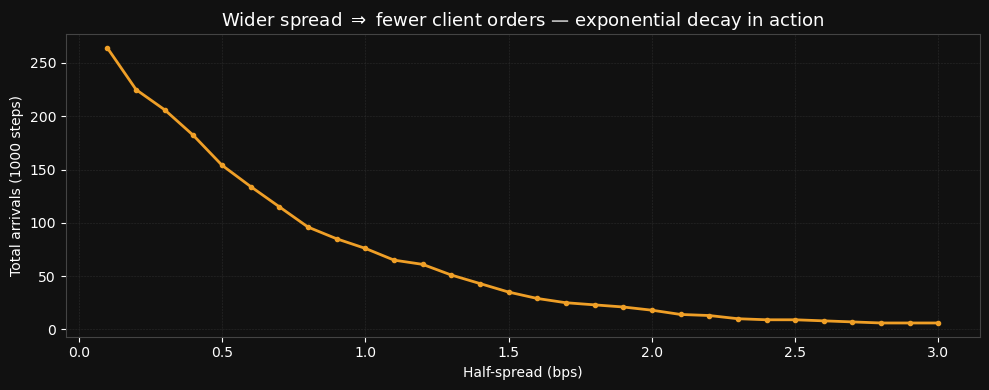

In [10]:
half_spreads_bps = np.arange(0.1, 3.1, 0.1)  # 0.1 to 3 bps
n_arrivals = []

for hs_bps in half_spreads_bps:
    hs = hs_bps / 10_000 * 1.10  # convert bps to price units for bid/ask
    test_bid = 1.10 - hs
    test_ask = 1.10 + hs
    test_gen = ClientFlowGenerator(config=cfg, seed=42)
    test_session = test_gen.generate_session(
        mid_prices=np.full(1001, 1.10),
        bid_prices=np.full(1001, test_bid),
        ask_prices=np.full(1001, test_ask),
        dt=0.1,
    )
    n_arrivals.append(len(test_session))

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')
ax.plot(half_spreads_bps, n_arrivals, color='#ef9f27', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Half-spread (bps)', color='white')
ax.set_ylabel('Total arrivals (1000 steps)', color='white')
ax.set_title('Wider spread $\\Rightarrow$ fewer client orders — exponential decay in action', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
for spine in ax.spines.values(): spine.set_color('#444444')
plt.tight_layout()
plt.show()